In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nicer
sns.set(style="whitegrid")
%matplotlib inline

#Research question: What makes a successful spotify artist or song?

In [3]:
# Load the CSV from the data folder
df = pd.read_csv("../data/SpotifyFeatures.csv")  

# Show first 5 rows
display(df.head())



,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [4]:
# Gives dataset info (columns, types, missing values)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  object 
 1   artist_name       232725 non-null  object 
 2   track_name        232724 non-null  object 
 3   track_id          232725 non-null  object 
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  object 
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  object 
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64
 16  time_signature    23

In [5]:
# row x column
df.shape

(232725, 18)

In [6]:
# Give column names
df.columns

Index(['genre', 'artist_name', 'track_name', 'track_id', 'popularity',
       'acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'key', 'liveness', 'loudness', 'mode',
       'speechiness', 'tempo', 'time_signature', 'valence'],
      dtype='object')

In [7]:
# Statistic summary for numeric columns
display(df.describe())

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000
mean,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,0.215009,-9.569885,0.120765,117.666585,0.454917
std,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,0.198273,5.998204,0.185518,30.898907,0.260065
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,0.097400,-11.771000,0.036700,92.959000,0.237000
50%,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,0.128000,-7.762000,0.050100,115.778000,0.444000
75%,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,0.264000,-5.501000,0.105000,139.054000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


In [8]:
# Check for missing values
display(df.isnull().sum())

genre               0
artist_name         0
track_name          1
track_id            0
popularity          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
dtype: int64

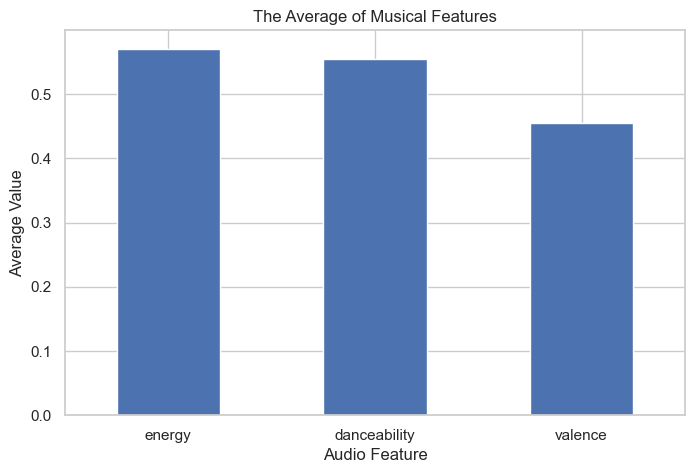

In [ ]:
#Q1: Which musical characteristics have the highest average values across the songs in the dataset?
#A: Between these 3 it is energy.
#make bar graph

features = ['danceability', 'energy', 'valence']

feature_means = df[features].mean().sort_values(ascending=False)

feature_means.plot(
    kind='bar',
    figsize=(8, 5),
    title='The Average of Musical Features'
)

plt.ylabel('Average Value')
plt.xlabel('Audio Feature')
plt.xticks(rotation=0)
plt.show()

In [15]:
#Tempo is in it's own scale so we measure the average tempo

average_tempo = df['tempo'].mean()

print(f"Average tempo: {average_tempo:.2f} BPM")

Average tempo: 117.67 BPM


In [18]:
#check avg popularity of each artists songs

artist_popularity = df.groupby('artist_name')['popularity'].mean()

artist_popularity.sort_values(ascending=False).head(20)

artist_name
Pedro Capó              87.000000
Mario Bautista          85.000000
Mau y Ricky             83.000000
Kris Kross Amsterdam    82.000000
Ninho                   82.000000
Paloma Mami             82.000000
Martin Garrix           81.857143
Sofia Reyes             81.500000
Kenny Man               81.000000
NSG                     81.000000
Anitta                  81.000000
Heuss L'enfoiré         81.000000
Billie Eilish           80.500000
Piso 21                 80.500000
Grupo Arranke           80.000000
Rombai                  80.000000
juan karlos             80.000000
Lele Pons               80.000000
Coolio                  80.000000
Ramz                    80.000000
Name: popularity, dtype: float64

In [19]:
#Account for number of songs artists released

artist_stats = df.groupby('artist_name').agg(
    avg_popularity=('popularity', 'mean'),
    track_count=('track_name', 'count')
).reset_index()

artist_stats.sort_values(
    'avg_popularity',
    ascending=False
).head(20)

,artist_name,avg_popularity,track_count
9840,Pedro Capó,87.000000,2
8203,Mario Bautista,85.000000,1
8370,Mau y Ricky,83.000000,2
7091,Kris Kross Amsterdam,82.000000,1
9285,Ninho,82.000000,1
9661,Paloma Mami,82.000000,3
8255,Martin Garrix,81.857143,7
11531,Sofia Reyes,81.500000,2
6876,Kenny Man,81.000000,2
9017,NSG,81.000000,1


In [24]:
#to have an even playing field we'll do artists with atleast 10 songs for avg popularity

established_artists = artist_stats[
    artist_stats['track_count'] >= 10
].sort_values(
    'avg_popularity',
    ascending=False
)

established_artists.head(20)



,artist_name,avg_popularity,track_count
1429,Billie Eilish,80.500000,20
14370,benny blanco,77.571429,14
10080,Post Malone,76.035294,85
9822,Paulo Londra,75.900000,10
6537,Juice WRLD,75.500000,40
3025,Danny Ocean,75.058824,17
9435,Offset,74.655172,58
6929,Khalid,74.437500,32
3204,December Avenue,74.000000,12
8512,Metro Boomin,73.000000,41


In [ ]:
#how many artists have more than 10 songs
len(established_artists)


4803

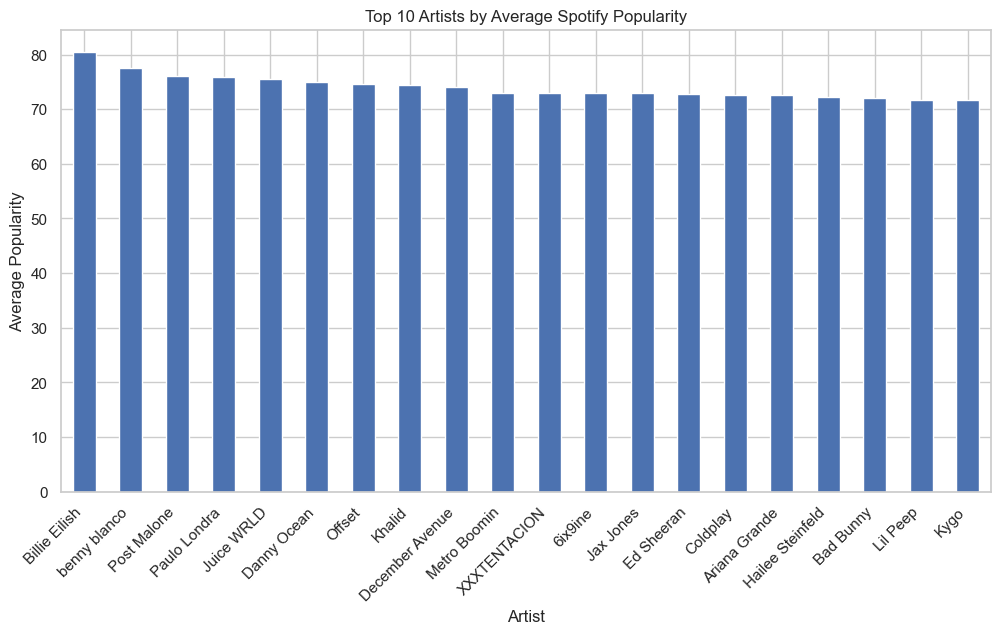

In [ ]:
#bar graph - Which artists have the highest average popularity among artists with a meaningful number of tracks in the dataset?
top_artists = established_artists.head(20)

top_artists.plot(
    x='artist_name',
    y='avg_popularity',
    kind='bar',
    figsize=(12, 6),
    legend=False,
    title='Top 20 Artists by Average Spotify Popularity'
)

plt.xlabel('Artist')
plt.ylabel('Average Popularity')
plt.xticks(rotation=45, ha='right')
plt.show()

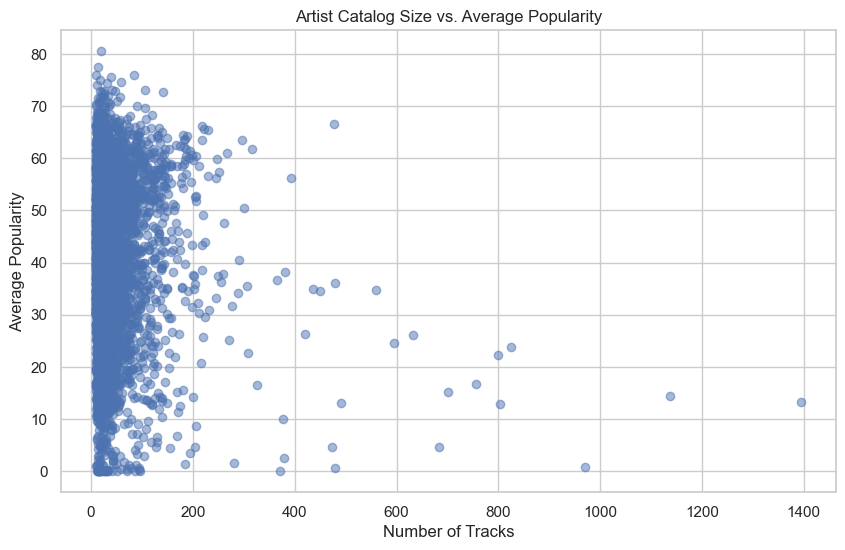

In [31]:
#A scatter plot showing if catalog size relates to popularity?

plt.figure(figsize=(10, 6))

plt.scatter(
    established_artists['track_count'],
    established_artists['avg_popularity'],
    alpha=0.5
)

plt.xlabel('Number of Tracks')
plt.ylabel('Average Popularity')
plt.title('Artist Catalog Size vs. Average Popularity')

plt.show()

In [32]:
#Look at the correlation
#As the number of tracks changes, does average popularity tend to change with it?

correlation = established_artists['track_count'].corr(
    established_artists['avg_popularity']
)

print(f"Correlation between track count and average popularity: {correlation:.3f}")

Correlation between track count and average popularity: -0.081
